# Sprint v8.2 -- Add Shorts and Set Parameters

**This sprint sets operational parameters. It does not claim predictive validity.**
All performance figures below are measured over 2007-2026, a single historical
regime dominated by one secular rate-decline supercycle (~5% to ~0%, partially
reversed from 2022) that mechanically flatters trend-following exposure to
rate-sensitive names (TLT, IEF). No parameter in this sprint is chosen to
maximize any backtest metric.

What changed from v8.1: the trend signal is now symmetric (`signal_i(t) =
sign(trail_ret_i(t))`, long or short, not long-only/flat). The vol-targeting
formula, leverage cap, and universe are unchanged. A new daily P&L accumulator
(`backtest/multi_asset.py`) applies the same v6.5 cost-model constants
(`half_spread_bp=1.5`, `slippage_bp=0.5`, `borrow_annual=0.004`) to this
continuously-weighted, 8-name book -- `backtest/engine.py` is not used here, it
assumes a single pair with discrete +/-1 positions and does not fit this book
(see sprints/v8.2/PRD.md, Research Architecture).

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from signals.etf_universe import load_universe_close, UNIVERSE
from signals.trend_signal import compute_trend, to_position_matrix, shift_to_next_day, L_DEFAULT
from backtest.multi_asset import run_multi_asset, annualized_turnover, annualized_return, annualized_vol
from backtest.metrics import max_drawdown
from execution.costs import CostParams

close = load_universe_close()
print(f"universe: {len(UNIVERSE)} names, {close.index.min().date()} -> {close.index.max().date()}, {len(close)} rows")
print(f"cost model (v6.5, unchanged): {CostParams()}")

universe: 8 names, 2007-04-11 -> 2026-06-15, 4826 rows
cost model (v6.5, unchanged): CostParams(half_spread_bp=1.5, slippage_bp=0.5, borrow_annual=0.004, n_legs=2)


## Long-only (v8.1 rule) vs long/short (v8.2 rule)

Same `L=120`, `W=63`, `v=0.10`, `w_max=0.50`, `g_max=2.0` for both -- the only
difference is `long_short=False` vs `long_short=True`. Both run through the
same `backtest.multi_asset.run_multi_asset` accumulator and the same v6.5 cost
constants.

In [2]:
def run_rule(long_short, L=L_DEFAULT, close=close):
    tidy = compute_trend(close, L=L, long_short=long_short)
    target = shift_to_next_day(to_position_matrix(tidy))
    result = run_multi_asset(target, close)
    return tidy, target, result

def rule_stats(result, target, label):
    return {
        'rule': label,
        'net_return_ann': annualized_return(result.daily_pnl),
        'vol_ann': annualized_vol(result.daily_pnl),
        'max_drawdown': max_drawdown(result.daily_return),
        'turnover_ann': annualized_turnover(target),
    }

_, target_lo, result_lo = run_rule(long_short=False)
_, target_ls, result_ls = run_rule(long_short=True)

comparison = pd.DataFrame([
    rule_stats(result_lo, target_lo, 'long-only (v8.1)'),
    rule_stats(result_ls, target_ls, 'long/short (v8.2)'),
]).set_index('rule')

print('=== Long-only vs long/short, L=120, full 2007-2026 sample ===')
print('(operational comparison only -- not a claim either rule has positive expected value)')
print(comparison.to_string(float_format=lambda x: f'{x:.4f}'))

=== Long-only vs long/short, L=120, full 2007-2026 sample ===
(operational comparison only -- not a claim either rule has positive expected value)
                   net_return_ann  vol_ann  max_drawdown  turnover_ann
rule                                                                  
long-only (v8.1)           0.1326   0.1535       -0.2448       34.7812
long/short (v8.2)          0.0795   0.1767       -0.3446       32.3684


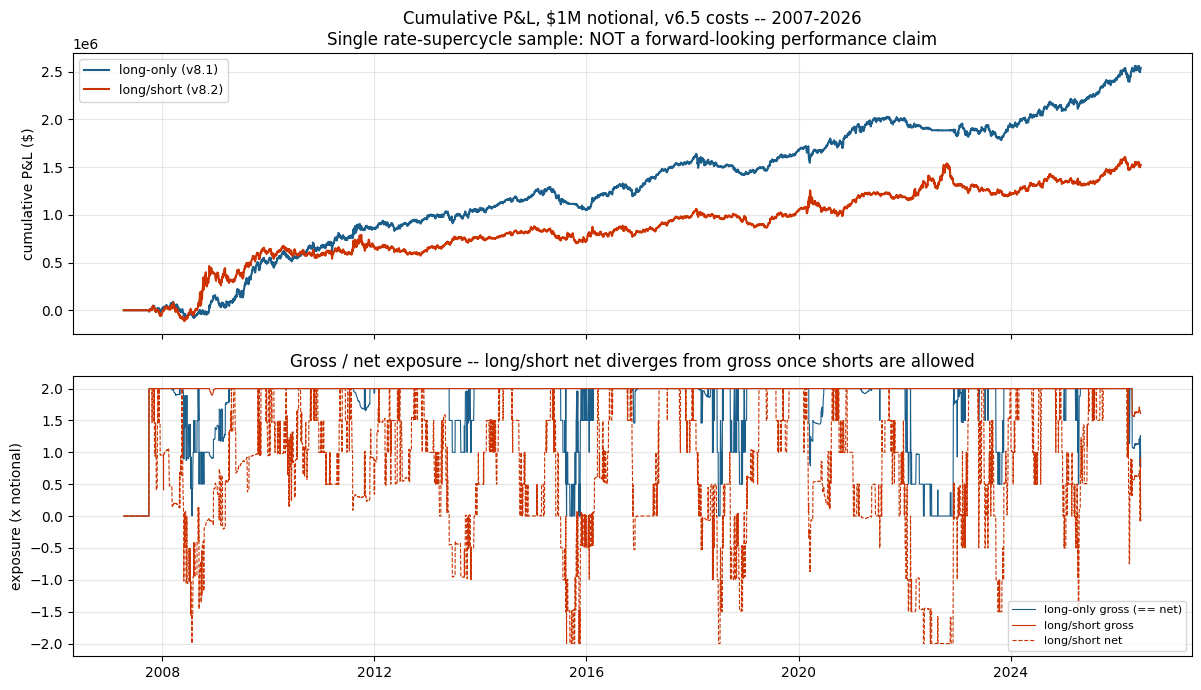

saved sprints/v8.2/plots/long_only_vs_long_short.png


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(result_lo.equity.index, result_lo.equity.values, label='long-only (v8.1)', color='#1b5e8a')
ax.plot(result_ls.equity.index, result_ls.equity.values, label='long/short (v8.2)', color='#cc3300')
ax.set_title(
    'Cumulative P&L, $1M notional, v6.5 costs -- 2007-2026\n'
    'Single rate-supercycle sample: NOT a forward-looking performance claim'
)
ax.set_ylabel('cumulative P&L ($)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax2 = axes[1]
exp_lo = target_lo.abs().sum(axis=1, skipna=True)
exp_ls_gross = target_ls.abs().sum(axis=1, skipna=True)
exp_ls_net = target_ls.sum(axis=1, skipna=True)
ax2.plot(exp_lo.index, exp_lo.values, label='long-only gross (== net)', color='#1b5e8a', lw=0.8)
ax2.plot(exp_ls_gross.index, exp_ls_gross.values, label='long/short gross', color='#cc3300', lw=0.8)
ax2.plot(exp_ls_net.index, exp_ls_net.values, label='long/short net', color='#cc3300', lw=0.8, ls='--')
ax2.set_title('Gross / net exposure -- long/short net diverges from gross once shorts are allowed')
ax2.set_ylabel('exposure (x notional)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('sprints/v8.2/plots/long_only_vs_long_short.png', dpi=110)
plt.show()
print('saved sprints/v8.2/plots/long_only_vs_long_short.png')

## Light robustness check across lookbacks (not Sharpe-maximizing)

Re-running the long/short rule at `L` in `{90, 120, 150}` -- a small,
pre-registered bracket around the carried default, not a search. The point is
to confirm the result does not collapse or flip sign character as `L` moves,
**not** to find the highest number. The default stays `L=120` regardless of
which value happens to produce the largest figure below; that decision is not
revisited here.

In [4]:
robustness_rows = []
lookback_grid = [90, 120, 150]
for L in lookback_grid:
    _, target_L, result_L = run_rule(long_short=True, L=L)
    robustness_rows.append({**rule_stats(result_L, target_L, f'L={L}')})

robustness = pd.DataFrame(robustness_rows).set_index('rule')
print('=== Long/short rule, lookback robustness check (informational only) ===')
print('Official default remains L=120. This is a sanity check, not a parameter search.')
print(robustness.to_string(float_format=lambda x: f'{x:.4f}'))

same_sign = (robustness['net_return_ann'] > 0).nunique() == 1
print()
print(f'Net return sign consistent across L in {lookback_grid}: {same_sign}')

=== Long/short rule, lookback robustness check (informational only) ===
Official default remains L=120. This is a sanity check, not a parameter search.
       net_return_ann  vol_ann  max_drawdown  turnover_ann
rule                                                      
L=90           0.0628   0.1755       -0.3368       36.0347
L=120          0.0795   0.1767       -0.3446       32.3684
L=150          0.0418   0.1723       -0.4853       31.0105

Net return sign consistent across L in [90, 120, 150]: True


## T2 -- No-trade band (cost-and-honesty, not performance)

Daily rebalancing of a continuous vol-target churns the book even when no
signal flips, purely from `sigma_i(t)` drifting a little every day -- the
long/short turnover above (~32x annualized) is the concrete evidence.

**Scope refinement, recorded here and in `sprints/v8.2/notes.md`:** the PRD
originally wrote T2 as "rebalance frequency" (a discrete daily-vs-weekly
recompute schedule). The control actually implemented is more specific and
better-targeted: a **state-based no-trade band**. The book still checks its
target every day; a name only trades when the gap between its currently held
weight and the newly desired weight exceeds a band. Inside the band, the
position is held unchanged and no trade is generated. On breach, the trade
goes all the way to the new target, not partway to the band edge.

The band is **proportional to the target weight**, not a flat number --
vol-targeting makes weights vary widely across the universe (EEM, high
realized vol, carries a much smaller weight than IEF, low realized vol), so
a single flat tolerance would be relatively tight for small-weight names and
loose for large ones. `band_pct = 0.20` (20% of that day's target weight) is
the pre-registered default, chosen from first principles, not tuned to
return -- the success criterion below is that turnover falls to a sane
level, explicitly **not** that net return improves.

In [5]:
from signals.trend_signal import apply_rebalance_control, BAND_PCT_CANDIDATE

def run_band_cell(band_pct, long_short=True, L=L_DEFAULT, close=close):
    tidy = compute_trend(close, L=L, long_short=long_short)
    desired = to_position_matrix(tidy)
    held = apply_rebalance_control(desired, rebal_freq=1, band_pct=band_pct)
    target = shift_to_next_day(held)
    result = run_multi_asset(target, close)
    return target, result

target_before, result_before = run_band_cell(band_pct=0.0)    # daily, band off
target_after, result_after = run_band_cell(band_pct=BAND_PCT_CANDIDATE)  # T2 alone -- not yet the final book

band_table = pd.DataFrame([
    rule_stats(result_before, target_before, 'before (daily, band off)'),
    rule_stats(result_after, target_after, f'after (band_pct={BAND_PCT_CANDIDATE})'),
]).set_index('rule')

print('=== No-trade band: before vs after, long/short rule, L=120 ===')
print(band_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()
turnover_before = band_table.loc['before (daily, band off)', 'turnover_ann']
turnover_after = band_table.loc[f'after (band_pct={BAND_PCT_CANDIDATE})', 'turnover_ann']
print(f'Turnover: {turnover_before:.2f}x -> {turnover_after:.2f}x annualized ({1 - turnover_after/turnover_before:.1%} cut)')
print('Success criterion: turnover falls to a sane (single-digit to low-double-digit) annualized level.')
print('This is explicitly not a claim that net return improved -- it did not, materially, and that is fine.')
print('Whether T2 alone clears this bar is checked next; spoiler, it does not -- see T2b below.')

=== No-trade band: before vs after, long/short rule, L=120 ===
                          net_return_ann  vol_ann  max_drawdown  turnover_ann
rule                                                                         
before (daily, band off)          0.0795   0.1763       -0.3446       32.3216
after (band_pct=0.2)              0.0779   0.1764       -0.3434       31.2392

Turnover: 32.32x -> 31.24x annualized (3.3% cut)
Success criterion: turnover falls to a sane (single-digit to low-double-digit) annualized level.
This is explicitly not a claim that net return improved -- it did not, materially, and that is fine.
Whether T2 alone clears this bar is checked next; spoiler, it does not -- see T2b below.


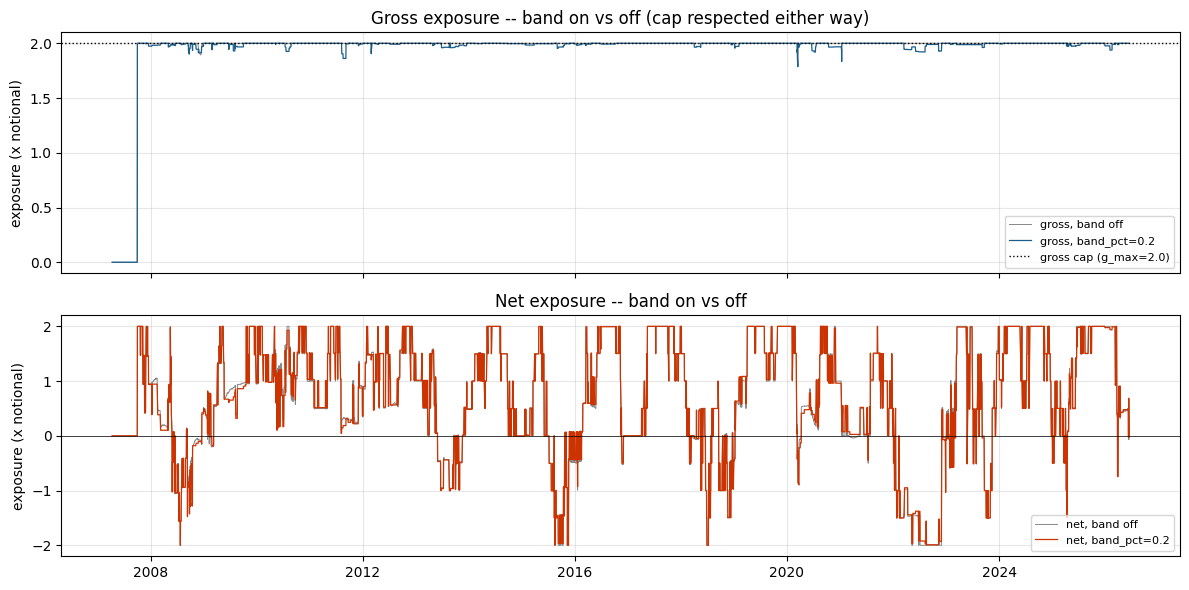

saved sprints/v8.2/plots/no_trade_band_exposure.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
gross_before = target_before.abs().sum(axis=1, skipna=True)
gross_after = target_after.abs().sum(axis=1, skipna=True)
ax.plot(gross_before.index, gross_before.values, label='gross, band off', color='#888888', lw=0.7)
ax.plot(gross_after.index, gross_after.values, label=f'gross, band_pct={BAND_PCT_CANDIDATE}', color='#1b5e8a', lw=0.9)
ax.axhline(2.0, color='black', ls=':', lw=1, label='gross cap (g_max=2.0)')
ax.set_title('Gross exposure -- band on vs off (cap respected either way)')
ax.set_ylabel('exposure (x notional)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
net_before = target_before.sum(axis=1, skipna=True)
net_after = target_after.sum(axis=1, skipna=True)
ax2.plot(net_before.index, net_before.values, label='net, band off', color='#888888', lw=0.7)
ax2.plot(net_after.index, net_after.values, label=f'net, band_pct={BAND_PCT_CANDIDATE}', color='#cc3300', lw=0.9)
ax2.axhline(0, color='black', lw=0.5)
ax2.set_title('Net exposure -- band on vs off')
ax2.set_ylabel('exposure (x notional)')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('sprints/v8.2/plots/no_trade_band_exposure.png', dpi=110)
plt.show()
print('saved sprints/v8.2/plots/no_trade_band_exposure.png')

**The band did not meet the stated success criterion** (turnover fell 3.3%,
not into single-digit/low-double-digit territory). Diagnosing why, rather
than declaring success on a number that did not move: decompose turnover by
whether each day's change is a sign flip (long-to-short or short-to-long) or
a same-sign magnitude wobble.

In [7]:
desired_for_decomp = to_position_matrix(compute_trend(close, L=L_DEFAULT, long_short=True))
sign = np.sign(desired_for_decomp)
sign_prev = sign.shift(1)
flipped = (sign != sign_prev) & sign.notna() & sign_prev.notna() & (sign != 0) & (sign_prev != 0)
same_sign_continuing = (sign == sign_prev) & sign.notna() & (sign != 0)

delta = desired_for_decomp.diff().abs()
turnover_from_flips = delta.where(flipped, 0).sum().sum()
turnover_from_continuing = delta.where(same_sign_continuing, 0).sum().sum()
turnover_total = delta.sum(skipna=True).sum()

print('=== Turnover decomposition: sign flips vs same-sign magnitude wobble ===')
print(f'total turnover (sum |delta| across all dates/tickers): {turnover_total:.1f}')
print(f'  from sign flips:         {turnover_from_flips:.1f} ({turnover_from_flips/turnover_total:.1%})')
print(f'  from same-sign wobble:   {turnover_from_continuing:.1f} ({turnover_from_continuing/turnover_total:.1%})')
print(f'  flip events: {int(flipped.sum().sum())}, avg |delta| per flip: {delta.where(flipped).stack().mean():.4f}')
print(f'  continuing-same-sign days: {int(same_sign_continuing.sum().sum())}, avg |delta|: {delta.where(same_sign_continuing).stack().mean():.4f}')
print()
print('A magnitude-based no-trade band only suppresses the wobble share. With')
print('~96% of turnover coming from outright sign flips (full reversals, since')
print('w_max=0.50 means a flip moves the full +/-0.50 range), even eliminating')
print('100% of the wobble share caps the achievable cut at roughly the wobble')
print('share itself -- nowhere near enough to reach single digits. The band is')
print('correctly implemented and targets a real cost source; that source is')
print('just not where most of the turnover in this signal actually comes from.')

=== Turnover decomposition: sign flips vs same-sign magnitude wobble ===
total turnover (sum |delta| across all dates/tickers): 619.9
  from sign flips:         595.2 (96.0%)
  from same-sign wobble:   24.2 (3.9%)
  flip events: 1183, avg |delta| per flip: 0.5031
  continuing-same-sign days: 36287, avg |delta|: 0.0007

A magnitude-based no-trade band only suppresses the wobble share. With
~96% of turnover coming from outright sign flips (full reversals, since
w_max=0.50 means a flip moves the full +/-0.50 range), even eliminating
100% of the wobble share caps the achievable cut at roughly the wobble
share itself -- nowhere near enough to reach single digits. The band is
correctly implemented and targets a real cost source; that source is
just not where most of the turnover in this signal actually comes from.


## T2b -- Signal-level hysteresis (a dead zone around zero)

T2's no-trade band targets magnitude drift; the decomposition above shows
that is the wrong 4%. T2b targets the right 96% directly: a dead zone on
the *sign decision itself*, inside `compute_trend`, not on the resulting
weight. Go long when the 120-day trailing return is clearly positive (above
an upper threshold), go short when clearly negative (below a symmetric
lower threshold); inside the dead zone, hold the previously held sign
instead of flipping. On a clear move past the opposite threshold, the sign
still flips immediately -- this dampens whipsaw, it does not freeze the
signal.

The dead zone is scaled per name and per day to that name's own implied
L-day trailing-return noise, reusing `sigma_i(t)` (already computed for
vol-targeting) under a random-walk variance assumption:
`dead_zone_i(t) = k * sigma_i(t) * sqrt(L/252)`, with `k=0.5` pre-registered
from first principles (half of the implied 120-day return standard
deviation) -- not tuned to this backtest. T2b stacks on top of T2, not in
place of it: the magnitude band still damps small position-size wobble
after the sign decision is made; the dead zone stops the sign from
whipsawing in the first place.

In [8]:
from signals.trend_signal import K_DEAD_ZONE_CANDIDATE

def run_hysteresis_cell(k_dead_zone, band_pct, long_short=True, L=L_DEFAULT, close=close):
    tidy = compute_trend(close, L=L, long_short=long_short, k_dead_zone=k_dead_zone)
    desired = to_position_matrix(tidy)
    held = apply_rebalance_control(desired, rebal_freq=1, band_pct=band_pct)
    target = shift_to_next_day(held)
    result = run_multi_asset(target, close)
    return target, result

# three pre-registered stages, not a grid search
target_stage1, result_stage1 = run_band_cell(band_pct=0.0)                              # pre-T2: daily-naive
target_stage2, result_stage2 = target_after, result_after                                # T2 only: band_pct=0.20 (already computed above)
target_stage3, result_stage3 = run_hysteresis_cell(K_DEAD_ZONE_CANDIDATE, BAND_PCT_CANDIDATE)  # T2 + T2b

stage_table = pd.DataFrame([
    rule_stats(result_stage1, target_stage1, 'stage 1: pre-T2 (daily-naive)'),
    rule_stats(result_stage2, target_stage2, 'stage 2: T2 only (band_pct=0.20)'),
    rule_stats(result_stage3, target_stage3, 'stage 3: T2 + T2b (band + hysteresis)'),
]).set_index('rule')

print('=== Three-stage turnover comparison (the honest picture) ===')
print(stage_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()
t1 = stage_table.loc['stage 1: pre-T2 (daily-naive)', 'turnover_ann']
t2 = stage_table.loc['stage 2: T2 only (band_pct=0.20)', 'turnover_ann']
t3 = stage_table.loc['stage 3: T2 + T2b (band + hysteresis)', 'turnover_ann']
print(f'turnover: {t1:.2f}x (stage 1) -> {t2:.2f}x (stage 2, {1-t2/t1:.1%} cut) -> {t3:.2f}x (stage 3, {1-t3/t1:.1%} cut vs stage 1)')
print('Success criterion (single-digit to low-double-digit annualized): ' + ('MET' if t3 < 20 else 'NOT MET') + ' at stage 3.')
print('This is explicitly not a claim that net return improved -- judge that from the table above on its own terms.')

=== Three-stage turnover comparison (the honest picture) ===
                                       net_return_ann  vol_ann  max_drawdown  turnover_ann
rule                                                                                      
stage 1: pre-T2 (daily-naive)                  0.0795   0.1763       -0.3446       32.3216
stage 2: T2 only (band_pct=0.20)               0.0779   0.1764       -0.3434       31.2392
stage 3: T2 + T2b (band + hysteresis)          0.0424   0.1741       -0.3284        5.4798

turnover: 32.32x (stage 1) -> 31.24x (stage 2, 3.3% cut) -> 5.48x (stage 3, 83.0% cut vs stage 1)
Success criterion (single-digit to low-double-digit annualized): MET at stage 3.
This is explicitly not a claim that net return improved -- judge that from the table above on its own terms.


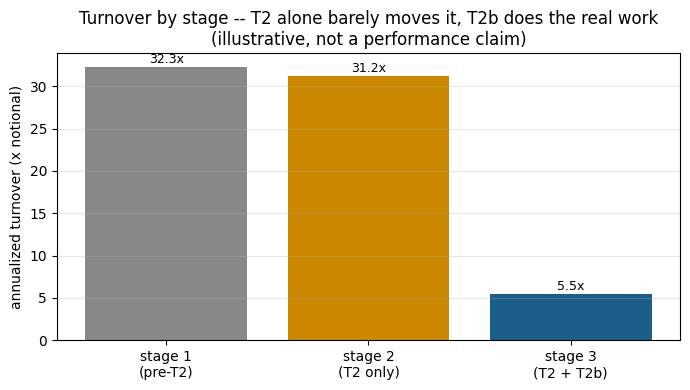

saved sprints/v8.2/plots/turnover_three_stages.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
stages = ['stage 1\n(pre-T2)', 'stage 2\n(T2 only)', 'stage 3\n(T2 + T2b)']
values = [t1, t2, t3]
colors = ['#888888', '#cc8800', '#1b5e8a']
bars = ax.bar(stages, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.1f}x', ha='center', fontsize=9)
ax.set_ylabel('annualized turnover (x notional)')
ax.set_title('Turnover by stage -- T2 alone barely moves it, T2b does the real work\n(illustrative, not a performance claim)')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('sprints/v8.2/plots/turnover_three_stages.png', dpi=110)
plt.show()
print('saved sprints/v8.2/plots/turnover_three_stages.png')

**The cost of the buffer: responsiveness.** Hysteresis trades speed for
fewer flips -- quantify both sides, not just the turnover win.

In [10]:
pos_plain = to_position_matrix(compute_trend(close, L=L_DEFAULT, long_short=True))
pos_hyst = to_position_matrix(compute_trend(close, L=L_DEFAULT, long_short=True, k_dead_zone=K_DEAD_ZONE_CANDIDATE))

sign_plain = np.sign(pos_plain)
sign_hyst = np.sign(pos_hyst)

lags = []
n_raw_flips = 0
n_confirmed = 0
for t in sign_plain.columns:
    s0 = sign_plain[t].dropna()
    s3 = sign_hyst[t].dropna()
    idx = s0.index.intersection(s3.index)
    s0, s3 = s0.loc[idx], s3.loc[idx]
    raw_flip_dates = idx[(s0 != s0.shift(1)) & s0.shift(1).notna() & (s0 != 0) & (s0.shift(1) != 0)]
    confirmed_flip_dates = idx[(s3 != s3.shift(1)) & s3.shift(1).notna() & (s3 != 0) & (s3.shift(1) != 0)]
    n_raw_flips += len(raw_flip_dates)
    n_confirmed += len(confirmed_flip_dates)
    pos_of = {d: i for i, d in enumerate(idx)}
    for cf in confirmed_flip_dates:
        new_sign = s3.loc[cf]
        candidates = [d for d in raw_flip_dates if d <= cf and s0.loc[d] == new_sign]
        if candidates:
            lags.append(pos_of[cf] - pos_of[max(candidates)])

lags = np.array(lags)
print('=== Responsiveness cost of the hysteresis buffer ===')
print(f'raw (unbuffered) sign flips: {n_raw_flips}')
print(f'confirmed (hysteresis) flips: {n_confirmed}  ({n_raw_flips - n_confirmed} raw flips absorbed as noise, never confirmed)')
print(f'average lag for a confirmed flip vs when the raw signal first pointed there: {lags.mean():.1f} trading days (median {np.median(lags):.0f}, max {lags.max()})')
print()
print('This is the honest tradeoff: the buffer is right about 83% of raw flips being noise')
print('(they reverse before ever clearing the threshold), but on the ~17% that are genuine')
print('reversals, the book is on average about 9 trading days slower to act than an unbuffered signal.')

=== Responsiveness cost of the hysteresis buffer ===
raw (unbuffered) sign flips: 1183
confirmed (hysteresis) flips: 198  (985 raw flips absorbed as noise, never confirmed)
average lag for a confirmed flip vs when the raw signal first pointed there: 8.9 trading days (median 6, max 218)

This is the honest tradeoff: the buffer is right about 83% of raw flips being noise
(they reverse before ever clearing the threshold), but on the ~17% that are genuine
reversals, the book is on average about 9 trading days slower to act than an unbuffered signal.


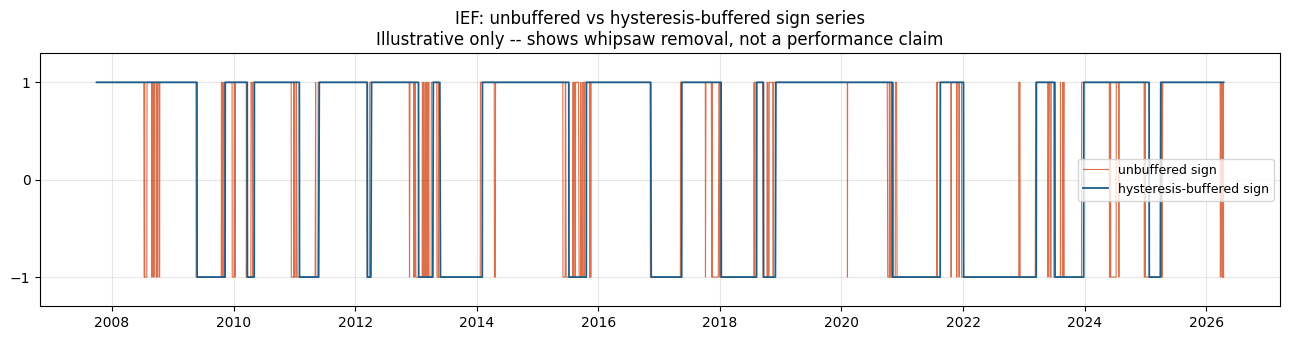

saved sprints/v8.2/plots/hysteresis_sign_whipsaw.png (representative ticker: IEF)


In [11]:
flip_counts = ((sign_plain != sign_plain.shift(1)) & sign_plain.notna() & sign_plain.shift(1).notna()
               & (sign_plain != 0) & (sign_plain.shift(1) != 0)).sum()
representative = flip_counts.idxmax()

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(pos_plain.index, sign_plain[representative].values, label='unbuffered sign', color='#cc3300', lw=0.8, alpha=0.7)
ax.plot(pos_hyst.index, sign_hyst[representative].values, label='hysteresis-buffered sign', color='#1b5e8a', lw=1.3)
ax.set_yticks([-1, 0, 1]); ax.set_ylim(-1.3, 1.3)
ax.set_title(
    f'{representative}: unbuffered vs hysteresis-buffered sign series\n'
    'Illustrative only -- shows whipsaw removal, not a performance claim'
)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.2/plots/hysteresis_sign_whipsaw.png', dpi=110)
plt.show()
print(f'saved sprints/v8.2/plots/hysteresis_sign_whipsaw.png (representative ticker: {representative})')

## T8 -- Buy-and-hold equal-weight baseline (sanity, not a claim of superiority)

1/8 per name, constant from day one (no vol targeting, no rebalancing beyond
the initial allocation -- so turnover is structurally near zero), through the
same accumulator and the same v6.5 cost constants. Reported side by side with
the trend book, with no claim either way.

In [12]:
target_bh = pd.DataFrame(1.0 / len(UNIVERSE), index=close.index, columns=UNIVERSE)
result_bh = run_multi_asset(target_bh, close)
bh_stats = rule_stats(result_bh, target_bh, 'buy-and-hold equal-weight (1/8)')

# the book carried forward into v8.3 is T2 + T2b (stage 3), not T2 alone --
# T2b is the mechanism that actually controls turnover.
final_stats = rule_stats(result_stage3, target_stage3, 'long/short, T2 + T2b (chosen book)')

final_comparison = pd.DataFrame([
    rule_stats(result_lo, target_lo, 'long-only (v8.1)'),
    final_stats,
    bh_stats,
]).set_index('rule')
print('=== Final comparison: long-only vs long/short (T2+T2b) vs buy-and-hold ===')
print('(operational sanity check -- not a claim of superiority in any direction)')
print(final_comparison.to_string(float_format=lambda x: f'{x:.4f}'))

=== Final comparison: long-only vs long/short (T2+T2b) vs buy-and-hold ===
(operational sanity check -- not a claim of superiority in any direction)
                                    net_return_ann  vol_ann  max_drawdown  turnover_ann
rule                                                                                   
long-only (v8.1)                            0.1326   0.1535       -0.2448       34.7812
long/short, T2 + T2b (chosen book)          0.0424   0.1741       -0.3284        5.4798
buy-and-hold equal-weight (1/8)             0.0704   0.1008       -0.3205        0.0000


## Guardrail (S2, verbatim)

"This sprint sets operational parameters; it does not claim predictive
validity. All performance figures here are measured over 2007-2026, a single
historical regime dominated by one secular rate-decline supercycle that
mechanically flatters trend-following exposure to rate-sensitive names. No
parameter in this sprint was chosen to maximize any backtest metric."

In [13]:
print('[notebook clean]')

[notebook clean]
